Abrindo o arquivo de treino, limpando a primeira linha para que não se confunda dados com títulos e nomeando cada uma das colunas. 

In [1]:
import pandas as pd
adult = pd.read_csv('/kaggle/input/adult-pmr3508/train_data.csv', 
names=["Age", "Workclass", "fnlwgt", "Education", "Education-Num", "Martial Status","Occupation", "Relationship", "Race", "Sex", "Capital Gain", "Capital Loss","Hours per week", "Country", "Income"], skiprows=1)


Analisando as primeiras linhas do arquivo

In [2]:
adult.head()

,Age,Workclass,fnlwgt,Education,Education-Num,Martial Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,Income
16280,34,Private,204991,Some-college,10,Divorced,Exec-managerial,Own-child,White,Male,0,0,44,United-States,<=50K
16281,58,Local-gov,310085,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
16282,25,Private,146117,Some-college,10,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,42,United-States,<=50K
16283,24,Private,138938,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
16284,57,Self-emp-inc,258883,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,60,Hungary,>50K


Resumo numérico da base de dados

In [3]:
adult.describe()

,Age,fnlwgt,Education-Num,Capital Gain,Capital Loss,Hours per week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Entendendo a distribuição geográfica das pessoas

In [4]:
adult ["Country"].value_counts()

Country
United-States                 29169
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France              

Entendendo o background das pessoas presentes na base de dados

In [5]:
import matplotlib.pyplot as plt

<Axes: ylabel='count'>

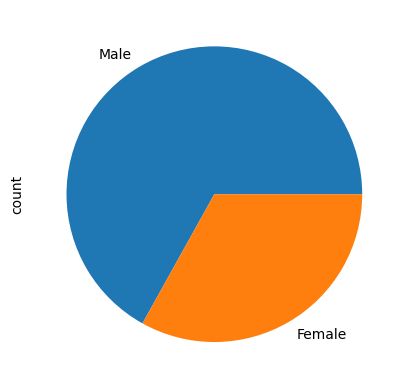

In [6]:
adult ["Sex"].value_counts().plot(kind="pie")

<Axes: xlabel='Education'>

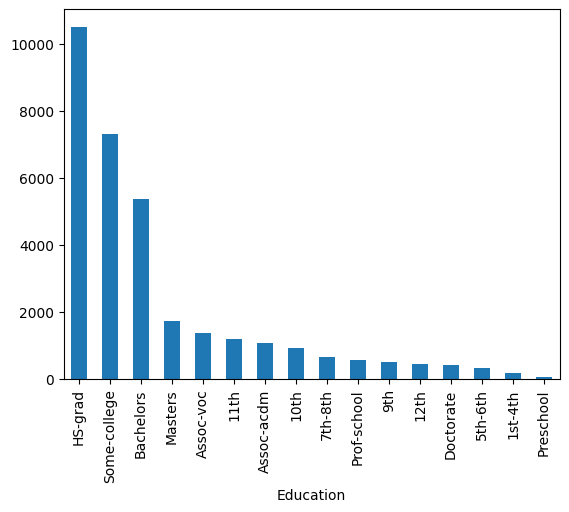

In [7]:
adult ["Education"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

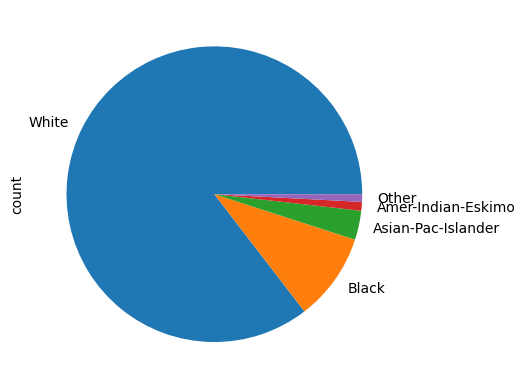

In [8]:
adult ["Race"].value_counts().plot(kind="pie")

Analisando os dados faltantes por categoria de dados.

In [9]:
import numpy as np


In [10]:
adult_n = adult.replace([' ?', '?'], np.nan)

In [11]:
adult_n.isnull().sum()


Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education-Num        0
Martial Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital Gain         0
Capital Loss         0
Hours per week       0
Country            583
Income               0
dtype: int64

Como são relativamente poucos os dados nulos ou incompletos, opta-se por eliminar esses dados.

In [12]:
adult_n = adult.dropna()

In [13]:
adult_n

,Age,Workclass,fnlwgt,Education,Education-Num,Martial Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,Income
16280,34,Private,204991,Some-college,10,Divorced,Exec-managerial,Own-child,White,Male,0,0,44,United-States,<=50K
16281,58,Local-gov,310085,10th,6,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
16282,25,Private,146117,Some-college,10,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,42,United-States,<=50K
16283,24,Private,138938,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
16284,57,Self-emp-inc,258883,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,60,Hungary,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,42,Private,384236,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,7688,0,40,United-States,>50K
48836,23,Private,129042,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K
48837,30,Private,195488,HS-grad,9,Never-married,Priv-house-serv,Own-child,White,Female,0,0,40,Guatemala,<=50K
48838,18,Private,27620,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,25,United-States,<=50K


Abrindo o arquivo de teste retirado da base de dados da UCI. Como o arquivo não contém títulos nas colunas, a primeira linha não é pulada, e as colunas são nomeadas da mesma forma que nos dados de treino.

In [14]:
teste_adult = pd.read_csv('/kaggle/input/adult-test/adult.test', 
names=["Age", "Workclass", "fnlwgt", "Education", "Education-Num", "Martial Status","Occupation", "Relationship", "Race", "Sex", "Capital Gain", "Capital Loss", "Hours per week", "Country", "Income"])

Faz-se o mesmo processo de eliminação de dados faltantes com a base de teste

In [15]:
teste_adult_n = teste_adult.replace([' ?', '?'], np.nan)

In [16]:
teste_adult_n = teste_adult.dropna()

Escolha dos atributos numéricos relevantes para a classificação:  "Age", "Education-Num", "Capital Gain", "Capital Loss", "Hours per week".

In [17]:
adult_x = adult_n[["Age", "Education-Num", "Capital Gain", "Capital Loss", "Hours per week"]]

In [18]:
adult_y = adult_n["Income"]

In [19]:
teste_adult_x = teste_adult_n[["Age", "Education-Num", "Capital Gain", "Capital Loss", "Hours per week"]]


In [20]:
teste_adult_y = teste_adult_n["Income"]

Testando para k=10

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
knn = KNeighborsClassifier(n_neighbors=10)

In [23]:
from sklearn.model_selection import cross_val_score

In [24]:
teste_adult_x = teste_adult_x[adult_x.columns]  

In [25]:
scores = cross_val_score(knn, adult_x, adult_y, cv=10)

In [26]:
scores

array([0.83200246, 0.83353808, 0.83998771, 0.83138821, 0.83169533,
       0.84029484, 0.82585995, 0.83445946, 0.83384521, 0.84275184])

In [27]:
knn.fit(adult_x,adult_y)

KNeighborsClassifier(n_neighbors=10)

Agora, é realizada a predição de "incomes" dos dados de teste de acordo com os atributos de teste analisados.

In [28]:
teste_adult_y_pred = knn.predict(teste_adult_x)

In [29]:
teste_adult_y_pred

array(['<=50K', '<=50K', '<=50K', ..., '>50K', '<=50K', '<=50K'],
      dtype=object)

In [30]:
teste_adult_y

1         <=50K.
2         <=50K.
3          >50K.
4          >50K.
5         <=50K.
          ...   
16277     <=50K.
16278     <=50K.
16279     <=50K.
16280     <=50K.
16281      >50K.
Name: Income, Length: 16281, dtype: object

In [31]:
teste_adult_y_clean = teste_adult_y.str.strip().str.replace('.', '', regex=False)

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(teste_adult_y_clean,teste_adult_y_pred)

0.8384005896443707

Testando para k=20

In [34]:
knn = KNeighborsClassifier(n_neighbors=20)

In [35]:
scores = cross_val_score(knn, adult_x, adult_y, cv=10)

In [36]:
scores

array([0.83538084, 0.83230958, 0.84398034, 0.8289312 , 0.83507371,
       0.84244472, 0.83046683, 0.82954545, 0.83568796, 0.84520885])

In [37]:
knn.fit(adult_x,adult_y)

KNeighborsClassifier(n_neighbors=20)

In [38]:
teste_adult_y_pred = knn.predict(teste_adult_x)

In [39]:
accuracy_score(teste_adult_y_clean,teste_adult_y_pred)

0.8409802837663534

Testando para k=30

In [40]:
knn = KNeighborsClassifier(n_neighbors=30)

In [41]:
scores = cross_val_score(knn, adult_x, adult_y, cv=10)

In [42]:
scores

array([0.83568796, 0.82800983, 0.83845209, 0.82923833, 0.83630221,
       0.8495086 , 0.82985258, 0.83138821, 0.83445946, 0.84367322])

In [43]:
knn.fit(adult_x,adult_y)

KNeighborsClassifier(n_neighbors=30)

In [44]:
teste_adult_y_pred = knn.predict(teste_adult_x)

In [45]:
accuracy_score(teste_adult_y_clean,teste_adult_y_pred)

0.8387076960874639

Depois de alguns testes, usa-se o cross validation para prever o melhor k a ser utilizado na base adult.

In [46]:
k_range = range(1, 31)
k_scores = []
k_std = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        knn_temp, adult_x, adult_y, 
        cv=30, scoring='accuracy', n_jobs=-1
    )
    
    k_scores.append(scores.mean())
    k_std.append(scores.std())

best_k = k_range[np.argmax(k_scores)]
best_score = max(k_scores)

print(f"Melhor K: {best_k} com acurácia: {best_score:.4f}")

Melhor K: 18 com acurácia: 0.8370


Passando todos os dados não-numéricos para valores numéricos, e fazendo alguns testes com vários conjuntos de atributos (mantendo k=18).

In [47]:
from sklearn import preprocessing

In [48]:
adult_num = adult_n.apply(preprocessing.LabelEncoder().fit_transform)

In [49]:
teste_adult_num = teste_adult_n.apply(preprocessing.LabelEncoder().fit_transform)

Assim, foram selecionados os seguintes atributos, considerados relevante e não redundantes para a clasificação por kNN:

In [50]:
adult_x = adult_num[["Age", "Education", "Occupation",  "Race", "Sex", "Capital Gain", "Capital Loss","Hours per week" ]]

In [51]:
adult_y = adult_num["Income"]

In [52]:
teste_adult_x = teste_adult_num[["Age", "Education", "Occupation", "Race", "Sex", "Capital Gain", "Capital Loss","Hours per week" ]]

In [53]:
teste_adult_y = teste_adult_num["Income"]

In [54]:
knn = KNeighborsClassifier(n_neighbors=18)

In [55]:
knn.fit(adult_x, adult_y)

KNeighborsClassifier(n_neighbors=18)

In [56]:
teste_adult_y_pred = knn.predict(teste_adult_x)

In [57]:
accuracy_score(teste_adult_y, teste_adult_y_pred)

0.8192371475953566

Agora, repete-se o mesmo procedimento para a base de teste disponível do Kaggle, a fim de submeter ao leaderboard.

In [58]:
teste_adult_2 = pd.read_csv('/kaggle/input/adult-pmr3508/test_data.csv', skiprows=1,
names=["Age", "Workclass", "fnlwgt", "Education", "Education-Num", "Martial Status","Occupation", "Relationship", "Race", "Sex", "Capital Gain", "Capital Loss", "Hours per week", "Country", "Income"])

In [59]:
teste_adult_2_n = teste_adult_2.replace([' ?', '?'], np.nan)

In [60]:
teste_aadult_2_n = teste_adult_2.dropna()

In [61]:
teste_adult_2_num = teste_adult_2_n.apply(preprocessing.LabelEncoder().fit_transform)

In [62]:
teste_adult_2_x = teste_adult_2_num[["Age", "Education", "Occupation", "Race", "Sex", "Capital Gain", "Capital Loss","Hours per week" ]]

In [63]:
teste_adult_2_y = teste_adult_2_num["Income"]

Repete-se o procedimento de escolha do melhor k, agora para a base de teste.

In [64]:
k_range = range(1, 31)
k_scores = []
k_std = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        knn_temp, teste_adult_2_x, teste_adult_2_y, 
        cv=30, scoring='accuracy', n_jobs=-1
    )
    
    k_scores.append(scores.mean())
    k_std.append(scores.std())

best_k = k_range[np.argmax(k_scores)]
best_score = max(k_scores)

print(f"Melhor K: {best_k} com acurácia: {best_score:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

Melhor K: 17 com acurácia: 0.9006


In [65]:
knn = KNeighborsClassifier(n_neighbors=17)

In [66]:
knn.fit(teste_adult_2_x, teste_adult_2_y)

KNeighborsClassifier(n_neighbors=17)

In [67]:
teste_adult_y_pred_2 = knn.predict(teste_adult_2_x)

Por fim, cria-se o arquivo csv para submissão do modelo.

In [68]:
df = pd.DataFrame({"Id": np.arange(0, teste_adult_y_pred_2.shape[0]),"income": teste_adult_y_pred_2})
df['income'] = df['income'].map({0: '<=50K', 1: '>50K'})
df = df.iloc[:16280]
df.to_csv("submission.csv", index=False)